# Sentiment Analysis Application Using Vertex AI

Complete end-to-end sentiment analysis pipeline for Twitter airline data.

**Pipeline**: Data Ingestion → Text Preprocessing → Data Preparation → Vertex AI Training → Evaluation

In [1]:
import vertex_ai_utils as vai
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
plt.style.use('default')

In [2]:
PROJECT_ID = "noted-cortex-477800-b7"
BUCKET_NAME = "vertex-ai-sentiment-data-msml610"
LOCATION = "us-central1"
DATA_PATH = "Data/Tweets.csv"
PROCESSED_DIR = "Data/processed"

Path(PROCESSED_DIR).mkdir(parents=True, exist_ok=True)

## 1. Data Ingestion

In [3]:
df = vai.load_twitter_data(DATA_PATH)
df[['text', 'airline_sentiment', 'airline']].head()

Successfully loaded 14640 tweets from Data/Tweets.csv


,text,airline_sentiment,airline
0,@VirginAmerica What @dhepburn said.,neutral,Virgin America
1,@VirginAmerica plus you've added commercials to the experience... tacky.,positive,Virgin America
2,@VirginAmerica I didn't today... Must mean I need to take another trip!,neutral,Virgin America
3,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &...",negative,Virgin America
4,@VirginAmerica and it's a really big bad thing about it,negative,Virgin America


In [4]:
vai.print_dataset_summary(df)

DATASET SUMMARY

 Basic Information:
Total Records: 14,640
Number of Columns: 15
Memory Usage: 9.87 MB

 Columns:
tweet_id                       - Type: int64      - Missing:      0 ( 0.00%)
airline_sentiment              - Type: object     - Missing:      0 ( 0.00%)
airline_sentiment_confidence   - Type: float64    - Missing:      0 ( 0.00%)
negativereason                 - Type: object     - Missing:  5,462 (37.31%)
negativereason_confidence      - Type: float64    - Missing:  4,118 (28.13%)
airline                        - Type: object     - Missing:      0 ( 0.00%)
airline_sentiment_gold         - Type: object     - Missing: 14,600 (99.73%)
name                           - Type: object     - Missing:      0 ( 0.00%)
negativereason_gold            - Type: object     - Missing: 14,608 (99.78%)
retweet_count                  - Type: int64      - Missing:      0 ( 0.00%)
text                           - Type: object     - Missing:      0 ( 0.00%)
tweet_coord                    - Type: 

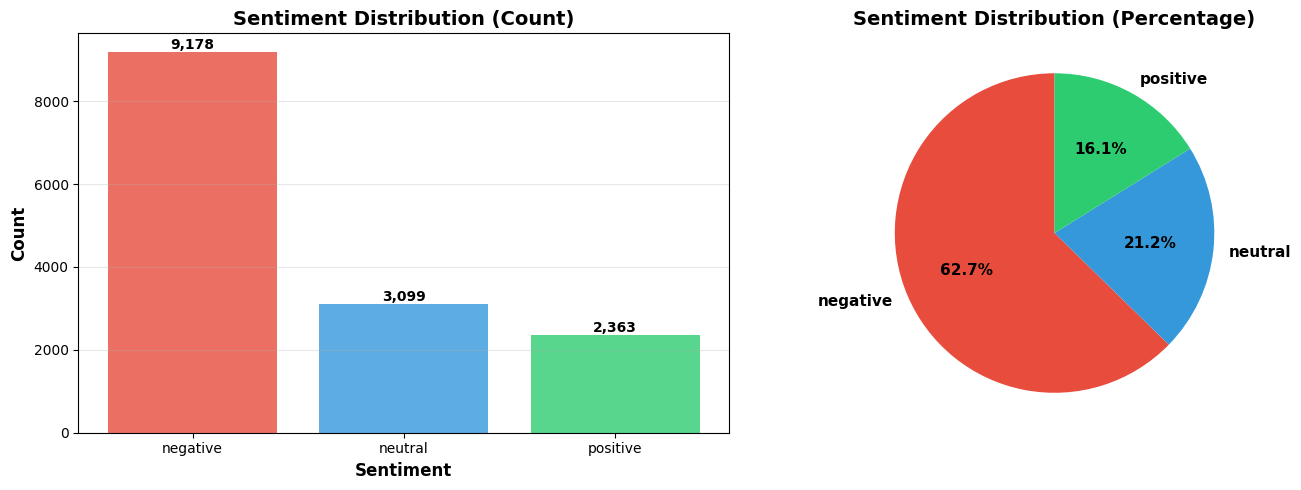

In [5]:
vai.visualize_sentiment_distribution(df)

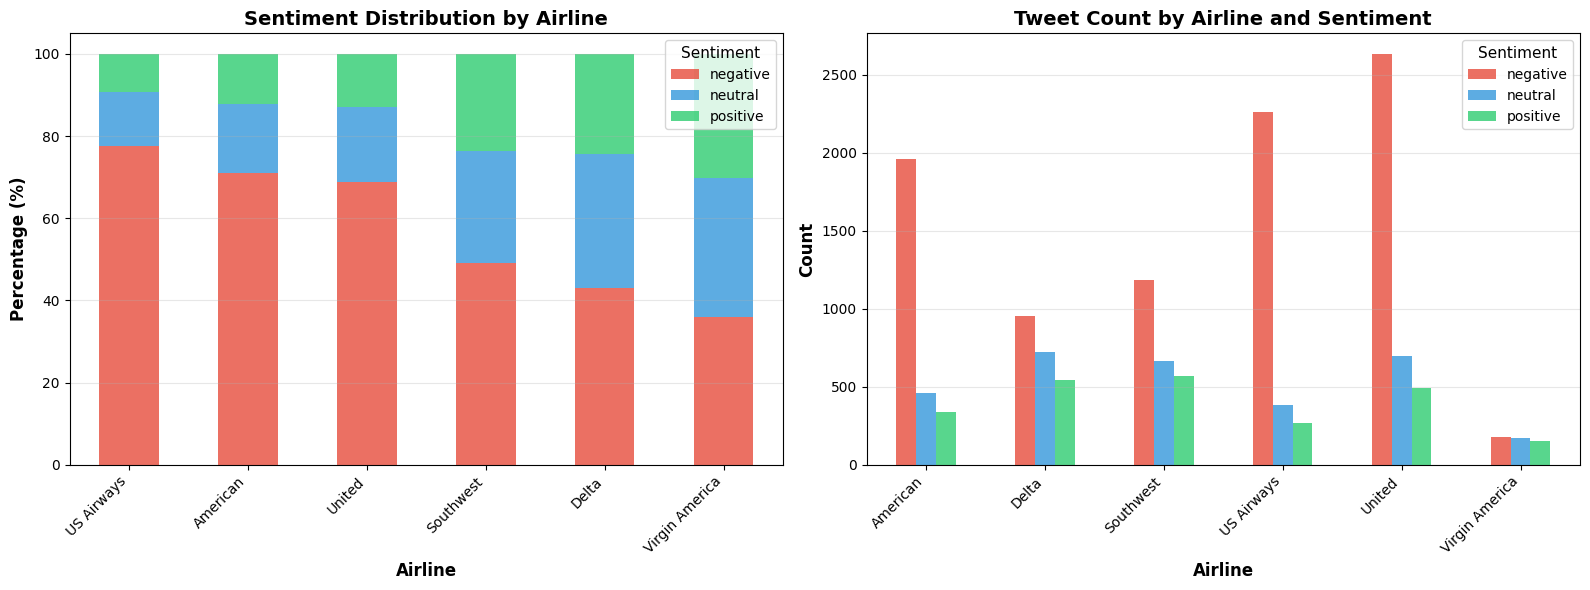

In [6]:
vai.visualize_airline_sentiment(df)

In [7]:
vai.print_text_statistics(df, text_column='text')

TEXT STATISTICS

 Text Length Statistics:
Mean: 103.82 characters
Median: 114.00 characters
Min: 12 characters
Max: 186 characters
Std Dev: 36.28 characters

 Word Count Statistics:
Mean: 17.65 words
Median: 19.00 words
Min: 2 words
Max: 36 words

 Content Features:
Tweets with URLs: 1,173 (8.01%)
Tweets with Mentions: 14,640 (100.00%)
Tweets with Hashtags: 2,489 (17.00%)
Average Exclamation Marks: 0.36
Average Question Marks: 0.32

Text Length by Sentiment:
neutral   :  87.36 chars, 14.41 words
positive  :  86.08 chars, 14.01 words
negative  : 113.95 chars, 19.69 words


In [8]:
vai.sample_tweets_by_sentiment(df, n_samples=3)

SAMPLE TWEETS BY SENTIMENT
POSITIVE TWEETS

1. Airline: Southwest | Confidence: 1.0
   Tweet: @SouthwestAir thanks for your excellent response time and assistance! All set :)

2. Airline: Delta | Confidence: 1.0
   Tweet: @JetBlue thanks. I appreciate your prompt response.

3. Airline: Delta | Confidence: 1.0
   Tweet: @JetBlue yes, with about 20 minutes to spare.  FYI - your employees are amazing.  Keep up the good work!
NEUTRAL TWEETS

1. Airline: United | Confidence: 0.3512
   Tweet: @united we finally just arrive to Bogota, good but long flight!!

2. Airline: American | Confidence: 0.6452
   Tweet: @AmericanAir got a callback at 1 am, took care of it. thanks.

3. Airline: Delta | Confidence: 1.0
   Tweet: @JetBlue is there wifi on he plain
NEGATIVE TWEETS

1. Airline: United | Confidence: 1.0
   Tweet: @united gate C 24 IAD. U released passengers to board w/others deplaning .50 peopleOn bridge while next flight  board http://t.co/HfoF33iyhi

2. Airline: US Airways | Confidence: 0.6

## 2. Text Preprocessing

Clean text: remove URLs, mentions, special characters, tokenize, remove stop words.

In [9]:
df_processed = vai.preprocess_dataframe(
    df,
    text_column='text',
    output_column='text_processed',
    remove_stopwords_flag=True,
    lemmatize=True,
    keep_negation=True
)

Preprocessing 14640 tweets...
NLTK punkt tokenizer not found. Using simple split.
NLTK punkt tokenizer not found. Using simple split.
NLTK punkt tokenizer not found. Using simple split.
NLTK punkt tokenizer not found. Using simple split.
NLTK punkt tokenizer not found. Using simple split.
NLTK punkt tokenizer not found. Using simple split.
NLTK punkt tokenizer not found. Using simple split.
NLTK punkt tokenizer not found. Using simple split.
NLTK punkt tokenizer not found. Using simple split.
NLTK punkt tokenizer not found. Using simple split.
NLTK punkt tokenizer not found. Using simple split.
NLTK punkt tokenizer not found. Using simple split.
NLTK punkt tokenizer not found. Using simple split.
NLTK punkt tokenizer not found. Using simple split.
NLTK punkt tokenizer not found. Using simple split.
NLTK punkt tokenizer not found. Using simple split.
NLTK punkt tokenizer not found. Using simple split.
NLTK punkt tokenizer not found. Using simple split.
NLTK punkt tokenizer not found. Us

In [10]:
vai.analyze_preprocessing_impact(
    df_processed,
    text_column='text',
    processed_column='text_processed'
)


 Text Length Statistics:
   Original:
  Mean: 103.8 chars
  Median: 114.0 chars
   Processed:
  Mean: 59.3 chars
  Median: 63.0 chars
   Reduction: 42.9%

 Word Count Statistics:
   Original:
  Mean: 17.7 words
  Median: 19.0 words
   Processed:
  Mean: 9.5 words
  Median: 10.0 words
   Reduction: 46.4%

Example 1:
  Original:  @SouthwestAir you're my early frontrunner for best airline! #oscars2016...
  Processed: youre early frontrunner best airline oscars2016...

Example 2:
  Original:  @USAirways how is it that my flt to EWR was Cancelled Flightled yet flts to NYC from USAirways are s...
  Processed: flt ewr cancelled flightled yet flts nyc usairways still flying...

Example 3:
  Original:  @JetBlue what is going on with your BDL to DCA flights yesterday and today?! Why is every single one...
  Processed: going bdl dca flight yesterday today every single one getting delayed...

Example 4:
  Original:  @JetBlue do they have to depart from Washington, D.C.??...
  Processed: depart wa

In [11]:
samples = df_processed.sample(5, random_state=42)
for i, (_, row) in enumerate(samples.iterrows(), 1):
    print(f"{i}. {row['airline_sentiment'].upper()}")
    print(f"   Original:  {row['text'][:100]}")
    print(f"   Processed: {row['text_processed'][:100]}\n")

1. POSITIVE
   Original:  @SouthwestAir you're my early frontrunner for best airline! #oscars2016
   Processed: youre early frontrunner best airline oscars2016

2. NEGATIVE
   Original:  @USAirways how is it that my flt to EWR was Cancelled Flightled yet flts to NYC from USAirways are s
   Processed: flt ewr cancelled flightled yet flts nyc usairways still flying

3. NEGATIVE
   Original:  @JetBlue what is going on with your BDL to DCA flights yesterday and today?! Why is every single one
   Processed: going bdl dca flight yesterday today every single one getting delayed

4. NEUTRAL
   Original:  @JetBlue do they have to depart from Washington, D.C.??
   Processed: depart washington dc

5. NEGATIVE
   Original:  @JetBlue I can probably find some of them. Are the ticket #s on there?
   Processed: probably find ticket



## 3. Data Splitting

In [12]:
train_df, val_df, test_df = vai.split_train_val_test(
    df_processed,
    train_ratio=0.7,
    val_ratio=0.15,
    test_ratio=0.15,
    random_state=42,
    stratify_column='airline_sentiment'
)

Training set:   10,248 records (70.0%)
Validation set:  2,196 records (15.0%)
Test set:        2,196 records (15.0%)

  Sentiment distribution verification:
   Train: positive: 16.15%  neutral: 21.17%  negative: 62.69%     Val  : positive: 16.12%  neutral: 21.17%  negative: 62.70%     Test : positive: 16.12%  neutral: 21.17%  negative: 62.70%  

## 4. Prepare for Vertex AI (JSONL Format)

In [13]:
train_path = vai.prepare_data_for_vertex_ai(
    train_df,
    text_column='text',
    label_column='airline_sentiment',
    output_path=f"{PROCESSED_DIR}/train.jsonl"
)

val_path = vai.prepare_data_for_vertex_ai(
    val_df,
    text_column='text',
    label_column='airline_sentiment',
    output_path=f"{PROCESSED_DIR}/val.jsonl"
)

test_path = vai.prepare_data_for_vertex_ai(
    test_df,
    text_column='text',
    label_column='airline_sentiment',
    output_path=f"{PROCESSED_DIR}/test.jsonl"
)

Saved to: Data/processed/train.jsonl
Saved to: Data/processed/val.jsonl
Saved to: Data/processed/test.jsonl


In [14]:
import json

with open(train_path, 'r') as f:
    for i, line in enumerate(f, 1):
        if i <= 3:
            record = json.loads(line)
            print(f"{i}. text: {record['text_content'][:60]}...")
            print(f"   category: {record['category']}\n")
        else:
            break

1. text: @AmericanAir since you don't care about what happens to your...
   category: negative

2. text: @united yea they been booked on 10 next avalible flights sin...
   category: negative

3. text: @JetBlue the departure time keeps getting Late Flightr.  I'l...
   category: negative



## 5. Vertex AI Setup

In [15]:
from google.cloud import aiplatform

# Use existing bucket for staging to avoid creating new buckets
vai.initialize_vertex_ai(
    project_id=PROJECT_ID,
    location=LOCATION,
    credentials_path="vertex-ai-key.json",
    staging_bucket=f"gs://{BUCKET_NAME}/staging"  # Use existing bucket with staging subfolder
)

print(f"\n⚠️  IMPORTANT: Using staging bucket: gs://{BUCKET_NAME}/staging")

✅ Loaded credentials from: vertex-ai-key.json
✅ Vertex AI initialized
   Project: noted-cortex-477800-b7
   Location: us-central1
   Staging bucket: gs://vertex-ai-sentiment-data-msml610/staging

⚠️  IMPORTANT: Using staging bucket: gs://vertex-ai-sentiment-data-msml610/staging


## 6. Upload to Google Cloud Storage

In [16]:
train_gcs = vai.upload_to_gcs(
    bucket_name=BUCKET_NAME,
    source_file_path=train_path,
    destination_blob_name="sentiment-data/train.jsonl"
)

val_gcs = vai.upload_to_gcs(
    bucket_name=BUCKET_NAME,
    source_file_path=val_path,
    destination_blob_name="sentiment-data/val.jsonl"
)

test_gcs = vai.upload_to_gcs(
    bucket_name=BUCKET_NAME,
    source_file_path=test_path,
    destination_blob_name="sentiment-data/test.jsonl"
)

print(f"Train: {train_gcs}")
print(f"Val: {val_gcs}")
print(f"Test: {test_gcs}")

✅ Uploaded Data/processed/train.jsonl to gs://vertex-ai-sentiment-data-msml610/sentiment-data/train.jsonl
✅ Uploaded Data/processed/val.jsonl to gs://vertex-ai-sentiment-data-msml610/sentiment-data/val.jsonl
✅ Uploaded Data/processed/test.jsonl to gs://vertex-ai-sentiment-data-msml610/sentiment-data/test.jsonl
Train: gs://vertex-ai-sentiment-data-msml610/sentiment-data/train.jsonl
Val: gs://vertex-ai-sentiment-data-msml610/sentiment-data/val.jsonl
Test: gs://vertex-ai-sentiment-data-msml610/sentiment-data/test.jsonl


## 7. Vertex AI Training (Custom RoBERTa)

**Transfer Learning**: RoBERTa pre-trained on 124M tweets

**Cost**: $15-25 for 30-60 min training

Uncomment to run:

In [17]:
# IMPORTANT: Reload the module to get latest changes
import importlib
import vertex_ai_utils
importlib.reload(vertex_ai_utils)
import vertex_ai_utils as vai

print("✅ Module reloaded successfully")

✅ Module reloaded successfully


In [18]:
from vertex_ai_utils import create_custom_roberta_training_job, run_roberta_training_job

job = create_custom_roberta_training_job(
    display_name="sentiment-roberta-training",
    script_path="vertex_ai_training.py",
    train_data_gcs_uri=train_gcs,
    val_data_gcs_uri=val_gcs,
    test_data_gcs_uri=test_gcs,
    project_id=PROJECT_ID,
    location=LOCATION
)

model = run_roberta_training_job(
    job=job,
    train_data_gcs_uri=train_gcs,
    val_data_gcs_uri=val_gcs,
    test_data_gcs_uri=test_gcs,
    model_display_name="airline-sentiment-roberta"
)

✅ Uploaded vertex_ai_training.py to gs://vertex-ai-sentiment-data-msml610/training_scripts/vertex_ai_training.py
🚀 Creating custom training job: sentiment-roberta-training
   ⏰ Estimated time: ~15-20 minutes (GPU)
   💰 Estimated cost: $2-5 USD
   Container: gcr.io/deeplearning-platform-release/pytorch-gpu.1-13:latest
   Machine: n1-standard-4 with NVIDIA T4 GPU
   Training script: gs://vertex-ai-sentiment-data-msml610/training_scripts/vertex_ai_training.py
   Hyperparameters:
     - learning_rate: 2e-05
     - batch_size: 32
     - weight_decay: 0.01
     - warmup_ratio: 0.1
     - num_epochs: 4
✅ Custom training job created: sentiment-roberta-training

   Call job.run() to start training
   Or call job.run(sync=False) to run asynchronously
🚀 Starting RoBERTa training job
   Data sources:
     - Train: gs://vertex-ai-sentiment-data-msml610/sentiment-data/train.jsonl
     - Val: gs://vertex-ai-sentiment-data-msml610/sentiment-data/val.jsonl
     - Test: gs://vertex-ai-sentiment-data-msm

## 8. Hyperparameter Tuning (PRODUCTION)

**Status**: ENABLED for production deployment  
**Cost**: $25-40 for 4-6 hours  
**Trials**: 10 max trials, 2 parallel  
**Optimization Metric**: F1-Macro (MAXIMIZE)

**Hyperparameters Being Tuned**:
- Learning Rate: 1e-5 to 5e-5 (log scale)
- Batch Size: [16, 32, 64]
- Weight Decay: 0.0 to 0.1 (linear scale)
- Warmup Ratio: 0.05 to 0.2 (linear scale)

**WARNING**: This will incur charges on your GCP account. The job will run automatically once executed.

In [19]:
from vertex_ai_utils import create_vertex_ai_hyperparameter_tuning_job

tuning_job = create_vertex_ai_hyperparameter_tuning_job(
    display_name="sentiment-hp-tuning",
    training_script_path="vertex_ai_training.py",
    train_data_gcs_uri=train_gcs,
    val_data_gcs_uri=val_gcs,
    test_data_gcs_uri=test_gcs,
    base_output_dir=f"gs://{BUCKET_NAME}/hp-tuning",
    max_trial_count=10,
    parallel_trial_count=2,
    project_id=PROJECT_ID,
    location=LOCATION
)

# Start the hyperparameter tuning (this will take ~2.5 hours)
tuning_job.run()

print("Hyperparameter tuning started! Check Vertex AI Console for progress.")

✅ Uploaded vertex_ai_training.py to gs://vertex-ai-sentiment-data-msml610/hyperparameter_tuning_scripts/vertex_ai_training.py
🚀 Creating hyperparameter tuning job: sentiment-hp-tuning
   Max trials: 10
   Parallel trials: 2
   ⏰ Estimated time: 150 minutes (GPU)
   💰 Estimated cost: $15-30 USD
   Container: gcr.io/deeplearning-platform-release/pytorch-gpu.1-13:latest
   Machine: n1-standard-4 with NVIDIA T4 GPU
   Training script: gs://vertex-ai-sentiment-data-msml610/hyperparameter_tuning_scripts/vertex_ai_training.py
✅ Hyperparameter tuning job created: sentiment-hp-tuning
   Metric to optimize: f1_macro (maximize)
   Search space:
     - learning_rate: [5e-6, 5e-5] (log scale)
     - batch_size: [16, 32]
     - weight_decay: [0.001, 0.1] (linear)
     - warmup_ratio: [0.0, 0.3] (linear)

   Call tuning_job.run() to start the job
Creating HyperparameterTuningJob
HyperparameterTuningJob created. Resource name: projects/326640294960/locations/us-central1/hyperparameterTuningJobs/405110

## 9. Model Deployment

**Cost**: $0.05-0.15/hour

Uncomment to run:

In [ ]:
from vertex_ai_utils import deploy_model_to_endpoint

endpoint = deploy_model_to_endpoint(
    model=model,
    endpoint_display_name="sentiment-endpoint",
    machine_type="n1-standard-2",
    min_replica_count=1,
    max_replica_count=5
)

NameError: name 'model' is not defined

## 10. Model Evaluation

**Metrics**: F1-Score (Macro/Weighted), Confusion Matrix

Uncomment to run:

In [ ]:
from vertex_ai_utils import evaluate_vertex_ai_model_predictions
from vertex_ai_utils import plot_vertex_ai_evaluation_results

test_texts = test_df['text'].tolist()
true_labels = test_df['airline_sentiment'].tolist()

results = evaluate_vertex_ai_model_predictions(
    endpoint=endpoint,
    test_texts=test_texts,
    true_labels=true_labels,
    output_path="evaluation_results.json"
)

plot_vertex_ai_evaluation_results(results)

print(f"F1-Macro: {results['f1_macro']:.4f}")
print(f"F1-Weighted: {results['f1_weighted']:.4f}")

## Expected Performance

- F1-Macro: 0.78-0.85
- F1-Weighted: 0.82-0.88
- Accuracy: 0.80-0.86

## Resource Cleanup

Uncomment to cleanup:

In [ ]:
from vertex_ai_utils import cleanup_vertex_ai_resources

cleanup_vertex_ai_resources(
    endpoints=[endpoint] if 'endpoint' in locals() else None,
    models=None,
    datasets=None
)